In [1]:
# This preice of code is to connect MSSQLServer with Python evniornament so that--
# we can export the cleaned data from SQL Server to python for Exploratory Data Analysis

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import pymssql

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

def get_connection():
    return pymssql.connect(
        server='localhost',
        port='1433',
        user='sa',
        password='Poor@b19',
        database='RFM_Analysis'
    )

engine = create_engine('mssql+pymssql://', creator=get_connection)
print("Connected to SQL!")

Connected to SQL!


In [2]:
# This will Load the data as per some requirements 

df = pd.read_sql("SELECT * FROM dbo.retail_clean", engine)

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])   # Convert text Based 'Invoicedate' to 'datetime' function 
df['TotalPrice'] = df['Quantity'] * df['Price']     # form a new column named 'TotalPrice' for calculating Price for all quantities combined 
df['Month'] = df['InvoiceDate'].dt.to_period('M') # Created a new 'Month' column that extracts just the year and month from the full date

print(f" Clean data loaded to Python !")
print(f"   Rows    : {len(df):,}")
print(f"   Columns : {df.columns.tolist()}")

 Clean data loaded to Python !
   Rows    : 805,549
   Columns : ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer_ID', 'Country', 'TotalPrice', 'Month']


In [3]:
print("=== DATA TYPES ===")
print(df.dtypes)

print("\n=== NULL CHECK ===")
print(df.isnull().sum())

print("\n=== BASIC STATISTICS ===")
print(df[['Quantity', 'Price', 'TotalPrice']].describe().round(2))

print("\n=== KEY METRICS ===")
print(f"Total revenue     : £{df['TotalPrice'].sum():,.2f}")
print(f"Avg order value   : £{df['TotalPrice'].mean():,.2f}")
print(f"Median order value: £{df['TotalPrice'].median():,.2f}")
print(f"Total customers   : {df['Customer_ID'].nunique():,}")
print(f"Total invoices    : {df['Invoice'].nunique():,}")
print(f"Total products    : {df['StockCode'].nunique():,}")

=== DATA TYPES ===
Invoice                   str
StockCode                 str
Description               str
Quantity                int64
InvoiceDate    datetime64[us]
Price                 float64
Customer_ID           float64
Country                   str
TotalPrice            float64
Month               period[M]
dtype: object

=== NULL CHECK ===
Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer_ID    0
Country        0
TotalPrice     0
Month          0
dtype: int64

=== BASIC STATISTICS ===
        Quantity      Price  TotalPrice
count  805549.00  805549.00   805549.00
mean       13.29       3.21       22.03
std       143.63      29.20      224.04
min         1.00       0.00        0.00
25%         2.00       1.25        4.95
50%         5.00       1.95       11.85
75%        12.00       3.75       19.50
max     80995.00   10953.50   168469.60

=== KEY METRICS ===
Total revenue     : £17,743,429.18
Avg order value   : £2

In [4]:
monthly_revenue = df.groupby('Month')['TotalPrice'].sum().reset_index()
monthly_revenue['Month'] = monthly_revenue['Month'].astype(str)
monthly_revenue


,Month,TotalPrice
0,2009-12,686654.160
1,2010-01,557319.062
2,2010-02,506371.066
3,2010-03,699608.991
4,2010-04,594609.192
5,2010-05,599985.790
6,2010-06,639066.580
7,2010-07,591636.740
8,2010-08,604242.650
9,2010-09,831615.001


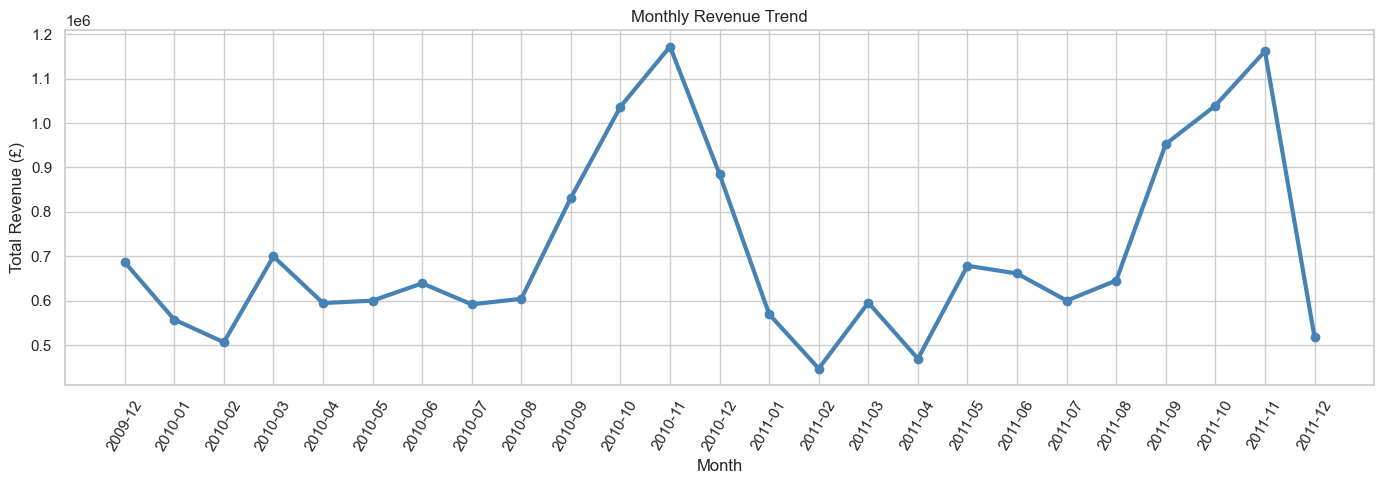

In [5]:
monthly_revenue = df.groupby('Month')['TotalPrice'].sum().reset_index()
monthly_revenue['Month'] = monthly_revenue['Month'].astype(str)

plt.figure(figsize=(14, 5))
plt.plot(monthly_revenue['Month'], monthly_revenue['TotalPrice'], 
         color='steelblue', marker = 'o', linewidth=3)
plt.xticks(rotation=60)
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue (£)')
plt.tight_layout()
plt.show()

In [6]:
yr2010 = df[df['Month'] == 2010]['TotalPrice'].sum()
yr2011 = df[df['Month'] == 2011]['TotalPrice'].sum()
growth = ((yr2011 - yr2010) / yr2010) * 100

/var/folders/vy/zdtjvtc135dgsm36hth1xnww0000gn/T/ipykernel_8253/330375528.py:3: RuntimeWarning: invalid value encountered in scalar divide
  growth = ((yr2011 - yr2010) / yr2010) * 100


In [7]:
df.isnull().sum()


Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer_ID    0
Country        0
TotalPrice     0
Month          0
dtype: int64

In [8]:
df.head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer_ID,Country,TotalPrice,Month
0,553014,85132B,CHARLIE AND LOLA TABLE TINS,2,2011-05-12 18:49:00,1.95,13451.0,United Kingdom,3.90,2011-05
1,553014,21212,PACK OF 72 RETROSPOT CAKE CASES,6,2011-05-12 18:49:00,0.55,13451.0,United Kingdom,3.30,2011-05
2,553014,21213,PACK OF 72 SKULL CAKE CASES,6,2011-05-12 18:49:00,0.55,13451.0,United Kingdom,3.30,2011-05
3,553014,84563A,PINK & WHITE BREAKFAST TRAY,2,2011-05-12 18:49:00,2.95,13451.0,United Kingdom,5.90,2011-05
4,553014,84563B,BLUE & WHITE BREAKFAST TRAY,1,2011-05-12 18:49:00,2.95,13451.0,United Kingdom,2.95,2011-05
5,553014,84519A,TOMATO CHARLIE+LOLA COASTER SET,4,2011-05-12 18:49:00,1.25,13451.0,United Kingdom,5.00,2011-05
6,553014,23108,SET OF 10 LED DOLLY LIGHTS,3,2011-05-12 18:49:00,6.25,13451.0,United Kingdom,18.75,2011-05
7,553014,23298,SPOTTY BUNTING,3,2011-05-12 18:49:00,4.95,13451.0,United Kingdom,14.85,2011-05
8,553014,47566,PARTY BUNTING,1,2011-05-12 18:49:00,4.95,13451.0,United Kingdom,4.95,2011-05
9,553014,84991,60 TEATIME FAIRY CAKE CASES,6,2011-05-12 18:49:00,0.55,13451.0,United Kingdom,3.30,2011-05


In [9]:

# Revenue by month name
df['MonthName'] = df['InvoiceDate'].dt.month
month_names = {1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr',
               5:'May', 6:'Jun', 7:'Jul', 8:'Aug',
               9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'}

monthly = df.groupby('MonthName')['TotalPrice'].sum().reset_index()
monthly['MonthLabel'] = monthly['MonthName'].map(month_names)
monthly = monthly.sort_values('MonthName')




In [11]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer_ID,Country,TotalPrice,Month,MonthName
0,553014,85132B,CHARLIE AND LOLA TABLE TINS,2,2011-05-12 18:49:00,1.95,13451.0,United Kingdom,3.90,2011-05,5
1,553014,21212,PACK OF 72 RETROSPOT CAKE CASES,6,2011-05-12 18:49:00,0.55,13451.0,United Kingdom,3.30,2011-05,5
2,553014,21213,PACK OF 72 SKULL CAKE CASES,6,2011-05-12 18:49:00,0.55,13451.0,United Kingdom,3.30,2011-05,5
3,553014,84563A,PINK & WHITE BREAKFAST TRAY,2,2011-05-12 18:49:00,2.95,13451.0,United Kingdom,5.90,2011-05,5
4,553014,84563B,BLUE & WHITE BREAKFAST TRAY,1,2011-05-12 18:49:00,2.95,13451.0,United Kingdom,2.95,2011-05,5


In [12]:
def categorise(desc):
    desc = str(desc).upper()
    if any(w in desc for w in ['CHRISTMAS','XMAS','SANTA','TREE','REINDEER']):
        return 'Christmas'
    elif any(w in desc for w in ['BAG','TOTE','SHOPPER','SATCHEL']):
        return 'Bags'
    elif any(w in desc for w in ['CANDLE','LIGHT','LANTERN','HOLDER']):
        return 'Lighting'
    elif any(w in desc for w in ['CAKE','KITCHEN','LUNCH','STORAGE','JAR']):
        return 'Kitchen'
    elif any(w in desc for w in ['PARTY','BUNTING','BALLOON','BANNER']):
        return 'Party'
    elif any(w in desc for w in ['FRAME','SIGN','WALL','MIRROR','DECOR']):
        return 'Home Decor'
    elif any(w in desc for w in ['CARD','WRAP','RIBBON','GIFT','PACK']):
        return 'Gift & Wrap'
    else:
        return 'Other'
    


    
    

In [13]:
df['Category'] = df['Description'].apply(categorise)
cat_revenue = df.groupby('Category')['TotalPrice'].sum().sort_values(ascending=False).reset_index()
cat_revenue

,Category,TotalPrice
0,Other,8997323.818
1,Home Decor,1838351.520
2,Lighting,1834735.610
3,Bags,1679419.410
4,Kitchen,1627130.270
5,Christmas,706279.810
6,Gift & Wrap,589427.170
7,Party,470761.570


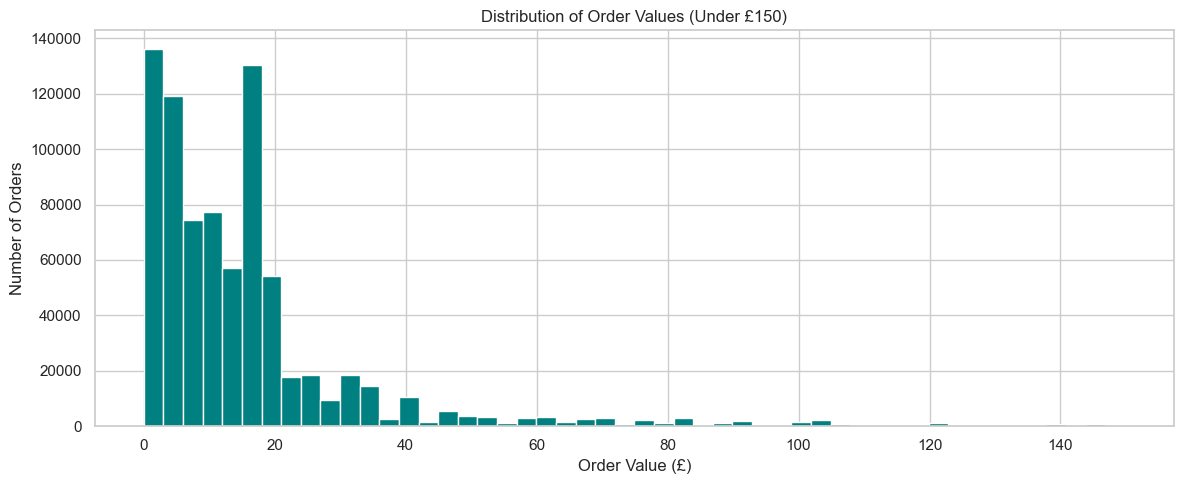

In [14]:
plt.figure(figsize=(12, 5))
df[df['TotalPrice'] < 150]['TotalPrice'].hist(bins=50, color='teal', edgecolor='white')
plt.title('Distribution of Order Values (Under £150)')
plt.xlabel('Order Value (£)')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.show()

In [15]:
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)
top_products 

Description
WORLD WAR 2 GLIDERS ASSTD DESIGNS     109169
WHITE HANGING HEART T-LIGHT HOLDER     93640
PAPER CRAFT , LITTLE BIRDIE            80995
ASSORTED COLOUR BIRD ORNAMENT          79913
MEDIUM CERAMIC TOP STORAGE JAR         77916
JUMBO BAG RED RETROSPOT                75759
BROCADE RING PURSE                     71129
PACK OF 60 PINK PAISLEY CAKE CASES     55270
60 TEATIME FAIRY CAKE CASES            53495
PACK OF 72 RETROSPOT CAKE CASES        46107
Name: Quantity, dtype: int64

/var/folders/vy/zdtjvtc135dgsm36hth1xnww0000gn/T/ipykernel_8253/3723978361.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products.values, y=top_products.index, palette ='Greens_r')


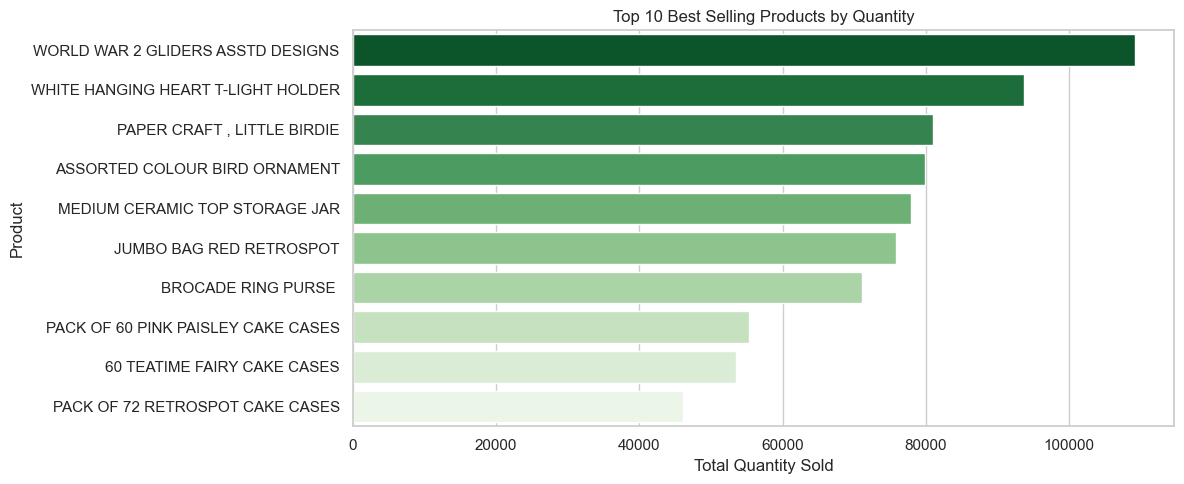

In [16]:
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 5))
sns.barplot(x=top_products.values, y=top_products.index, palette ='Greens_r')
plt.title('Top 10 Best Selling Products by Quantity')
plt.xlabel('Total Quantity Sold')
plt.ylabel('Product')
plt.tight_layout()
plt.show()

In [17]:
top_countries = df['Country'].value_counts().head(10)
top_countries

Country
United Kingdom    725250
Germany            16694
EIRE               15743
France             13812
Netherlands         5088
Spain               3719
Belgium             3068
Switzerland         3011
Portugal            2446
Australia           1812
Name: count, dtype: int64

/var/folders/vy/zdtjvtc135dgsm36hth1xnww0000gn/T/ipykernel_8253/701833035.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette='Blues_r')


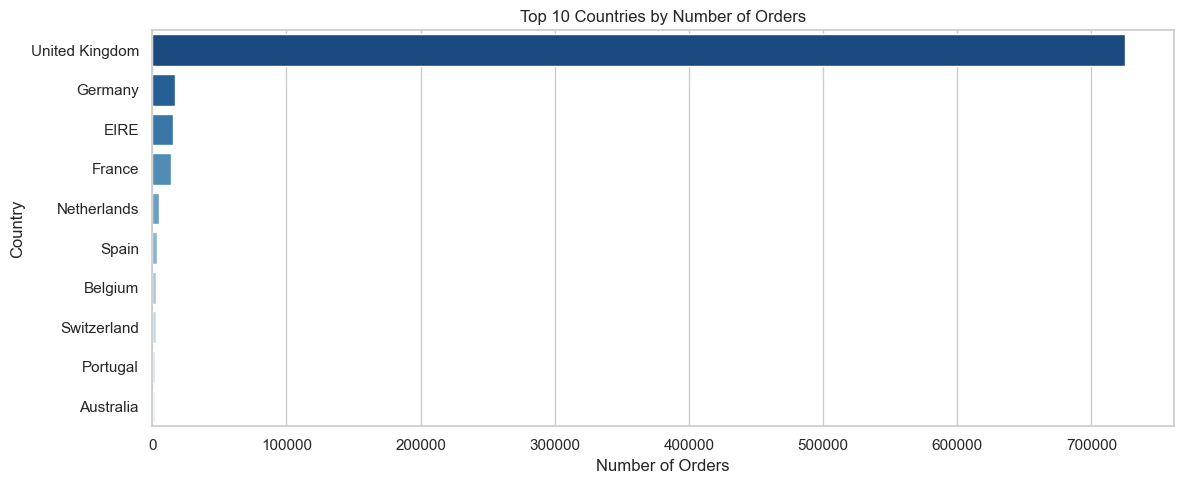

In [18]:
top_countries = df['Country'].value_counts().head(10)

plt.figure(figsize=(12, 5))
sns.barplot(x=top_countries.values, y=top_countries.index, palette='Blues_r')
plt.title('Top 10 Countries by Number of Orders')
plt.xlabel('Number of Orders')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

In [19]:
monthly_customers = df.groupby('Month')['Customer_ID'].nunique().reset_index()
monthly_customers['Month'] = monthly_customers['Month'].astype(str)
monthly_customers

,Month,Customer_ID
0,2009-12,955
1,2010-01,720
2,2010-02,772
3,2010-03,1057
4,2010-04,942
5,2010-05,966
6,2010-06,1041
7,2010-07,928
8,2010-08,911
9,2010-09,1145


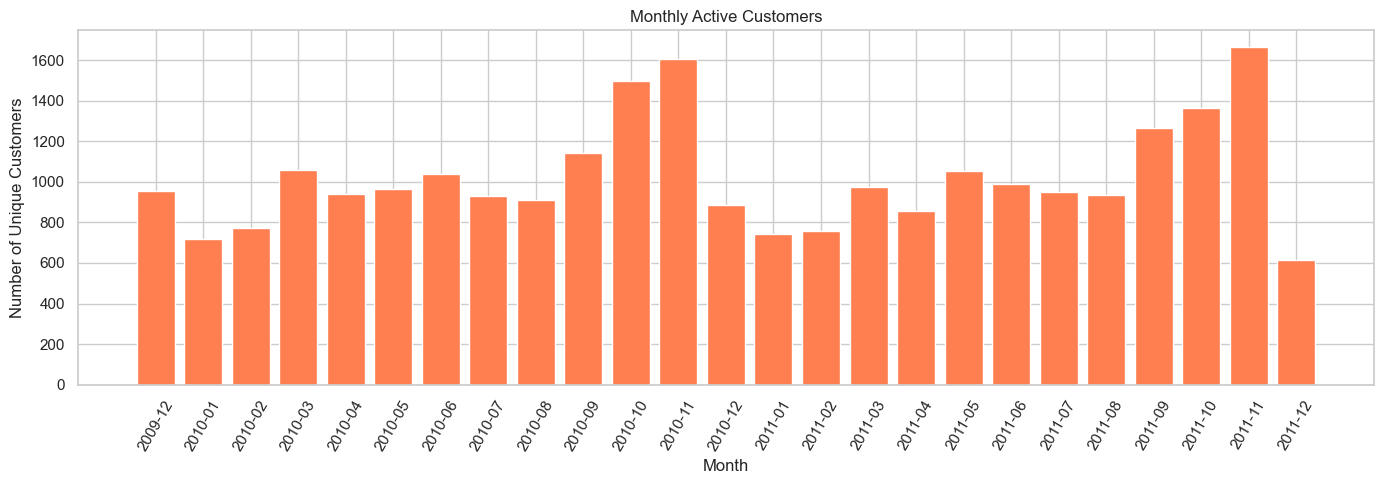

In [20]:
monthly_customers = df.groupby('Month')['Customer_ID'].nunique().reset_index()
monthly_customers['Month'] = monthly_customers['Month'].astype(str)

plt.figure(figsize=(14, 5))
plt.bar(monthly_customers['Month'], monthly_customers['Customer_ID'], color='coral')
plt.xticks(rotation=60)
plt.title('Monthly Active Customers')
plt.xlabel('Month')
plt.ylabel('Number of Unique Customers')
plt.tight_layout()
plt.show()

In [21]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer_ID,Country,TotalPrice,Month,MonthName,Category
0,553014,85132B,CHARLIE AND LOLA TABLE TINS,2,2011-05-12 18:49:00,1.95,13451.0,United Kingdom,3.90,2011-05,5,Other
1,553014,21212,PACK OF 72 RETROSPOT CAKE CASES,6,2011-05-12 18:49:00,0.55,13451.0,United Kingdom,3.30,2011-05,5,Kitchen
2,553014,21213,PACK OF 72 SKULL CAKE CASES,6,2011-05-12 18:49:00,0.55,13451.0,United Kingdom,3.30,2011-05,5,Kitchen
3,553014,84563A,PINK & WHITE BREAKFAST TRAY,2,2011-05-12 18:49:00,2.95,13451.0,United Kingdom,5.90,2011-05,5,Other
4,553014,84563B,BLUE & WHITE BREAKFAST TRAY,1,2011-05-12 18:49:00,2.95,13451.0,United Kingdom,2.95,2011-05,5,Other
